In [1]:
import pandas as pd
import numpy as np

In [2]:
tenders = pd.read_csv(r'/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-odisha/data_extractor/TENDERS/data/heattenders_districtgeotagged.csv')


In [3]:
tenders.head()
tenders['Awarded Value'] = tenders['Awarded Value'].str.replace(',', '').astype(float)
tenders['Awarded Value USD'] = tenders['Awarded Value'] / 94.3  # USD/INR rate as of 2026-06-21


In [4]:
heat_response = tenders.groupby('Heat Response - Themes')['Awarded Value'].sum().round(2)
heat_response = heat_response.sort_values()
heat_response

Heat Response - Themes
Cooling & Reflective Infrastructure    2.303043e+06
Greening & Urban Forestry              2.533738e+07
Awareness & Capacity Building          4.702656e+07
Shelter & Rest Infrastructure          1.022824e+09
Heatwave & Emergency Response          4.490220e+09
Drinking Water & Hydration             1.727252e+10
Name: Awarded Value, dtype: float64

In [5]:
heat_response = heat_response * 0.0104
heat_response

Heat Response - Themes
Cooling & Reflective Infrastructure    2.395165e+04
Greening & Urban Forestry              2.635088e+05
Awareness & Capacity Building          4.890762e+05
Shelter & Rest Infrastructure          1.063737e+07
Heatwave & Emergency Response          4.669829e+07
Drinking Water & Hydration             1.796342e+08
Name: Awarded Value, dtype: float64

In [6]:
strong_heat_tenders = tenders[tenders['heat_signal'] == 'strong']
strong_heat_tenders

,Tender ID,tender_externalreference,tender_title,Work Description,Tender Category,Tender Type,Form of contract,Product Category,Is Multi Currency Allowed For BOQ,Allow Two Stage Bidding,...,Scheme,Response Type,Heat Response - Themes,Heat Response - Subhead,month,tender_district_externalReference,tender_district_title_description,tender_district_location,DISTRICT_FINALISED,Awarded Value USD
21,2025_WCUTT_121529_1,GMWATCO (W)-10(1)/2025-26 Dtd.14.11.2025,Construction of DRINKING WATER KIOSK at Malach...,Construction of DRINKING WATER KIOSK at Malach...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2025_12,NaN,Cuttack,Cuttack,Cuttack,7602.195122
288,2025_PHEO_123487_1,27 OF 2025-26,Construction of water Kiosk at Kamakhyanagar N...,Construction of water Kiosk at Kamakhyanagar N...,Works,Open Tender,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'water kiosk':...,2026_04,NaN,Dhenkanal,NaN,Dhenkanal,21639.703075
662,2025_ORULB_111543_12,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_08,NaN,NaN,NaN,NaN,20383.616119
665,2025_ORULB_111543_11,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_08,NaN,NaN,NaN,NaN,12563.128314
875,2025_WCUTT_123255_1,GMWATCO (W)-13(5)/2025-26 Dtd.09.12.2025,Construction of DRINKING WATER KIOSK in front ...,Construction of DRINKING WATER KIOSK in front ...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2026_02,NaN,Cuttack,Cuttack,Cuttack,6594.517497
879,2025_WCUTT_123251_1,GMWATCO (W)-13(4)/2025-26 Dtd.09.12.2025,Construction of DRINKING WATER KIOSK at Sishub...,Construction of DRINKING WATER KIOSK at Sishub...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2026_02,NaN,Cuttack,Cuttack,Cuttack,6594.517497
888,2025_WCUTT_123245_1,GMWATCO (W)-13(2)/2025-26 Dtd.09.12.2025,Construction of DRINKING WATER KIOSK at Sahid ...,Construction of DRINKING WATER KIOSK at Sahid ...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2026_02,NaN,Cuttack,Cuttack,Cuttack,6658.292683
891,2025_WCUTT_123247_1,GMWATCO (W)-13(3)/2025-26 Dtd.09.12.2025,Construction of DRINKING WATER KIOSK near Koch...,Construction of DRINKING WATER KIOSK near Koch...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2026_02,NaN,Cuttack,Cuttack,Cuttack,6594.655355
897,2025_WCUTT_123241_1,GMWATCO (W)-13(1)/2025-26 Dtd.09.12.2025,Construction of DRINKING WATER KIOSK at CDA Ma...,Construction of DRINKING WATER KIOSK at CDA Ma...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2026_02,NaN,Cuttack,Cuttack,Cuttack,6615.705196
1190,2025_WCUTT_121650_1,GMWATCO (W)-11(3)/2025-26 Dtd.17.11.2025,Construction of DRINKING W

In [7]:
import re
heat_terms = [
    'heat wave', 'heatwave', 'heat-wave',
    'heat relief', 'heat releif',
    'extreme heat', 'heat stress', 'heat stroke', 'heat exhaustion',
    'heat advisory', 'heat alert', 'heat warning', 'heat hotline',
    'heat action plan', 'heat resilien', 'sunstroke', 'sun stroke',
]

pattern = '|'.join(re.escape(t) for t in heat_terms)

text_cols = ['tender_title', 'Work Description', 'tender_externalreference']
search_text = tenders[text_cols].fillna('').agg(' '.join, axis=1).str.lower()

explicit_heat_tenders = tenders[search_text.str.contains(pattern, regex=True)]
explicit_heat_tenders


,Tender ID,tender_externalreference,tender_title,Work Description,Tender Category,Tender Type,Form of contract,Product Category,Is Multi Currency Allowed For BOQ,Allow Two Stage Bidding,...,Scheme,Response Type,Heat Response - Themes,Heat Response - Subhead,month,tender_district_externalReference,tender_district_title_description,tender_district_location,DISTRICT_FINALISED,Awarded Value USD
662,2025_ORULB_111543_12,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_08,NaN,NaN,NaN,NaN,20383.616119
665,2025_ORULB_111543_11,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_08,NaN,NaN,NaN,NaN,12563.128314
1347,2025_ORULB_111543_8,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_06,NaN,NaN,NaN,NaN,9422.354189
1350,2025_ORULB_111543_9,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_06,NaN,NaN,NaN,NaN,NaN
1373,2025_ORULB_111543_10,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_06,NaN,NaN,NaN,NaN,9422.354189
1376,2025_ORULB_111543_7,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_06,NaN,NaN,NaN,NaN,NaN
1578,2025_ORULB_111543_3,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_05,NaN,NaN,NaN,NaN,11556.595970


/var/folders/mn/tyjcr2q91wz11fzw0ttcj3780000gn/T/ipykernel_23343/2044789224.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(summary.index, rotation=30, ha='right')


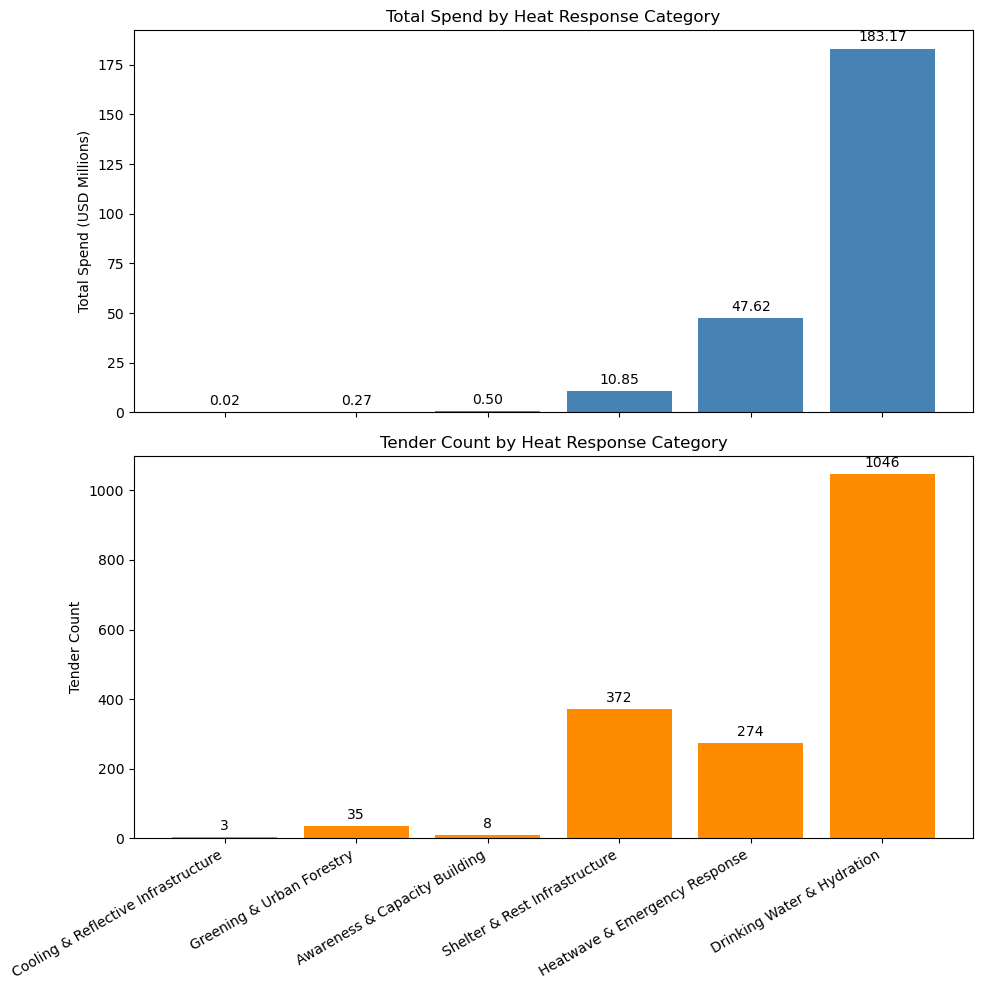

In [8]:
import matplotlib.pyplot as plt

summary = tenders.groupby('Heat Response - Themes')['Awarded Value USD'].agg(
    total_spend='sum', tender_count='count'
).sort_values('total_spend')

summary['total_spend_millions'] = summary['total_spend'] / 1e6

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

bars1 = ax1.bar(summary.index, summary['total_spend_millions'], color='steelblue')
ax1.set_ylabel('Total Spend (USD Millions)')
ax1.set_title('Total Spend by Heat Response Category')
ax1.bar_label(bars1, fmt='%.2f', padding=3)

bars2 = ax2.bar(summary.index, summary['tender_count'], color='darkorange')
ax2.set_ylabel('Tender Count')
ax2.set_title('Tender Count by Heat Response Category')
ax2.bar_label(bars2, padding=3)
ax2.set_xticklabels(summary.index, rotation=30, ha='right')

fig.tight_layout()
plt.show()


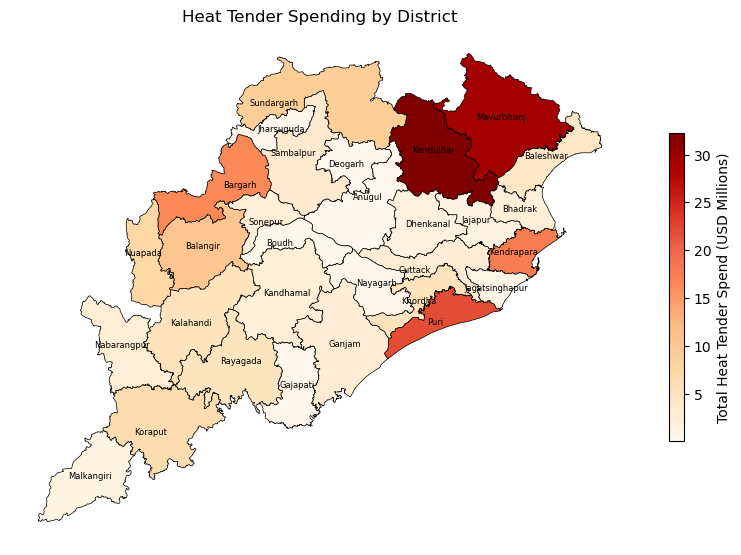

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

district_geo = gpd.read_file(
    '/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-odisha/data_extractor/assets/district.geojson'
)
district_geo = district_geo.dissolve(by='dtname', as_index=False)

district_spend = (
    tenders.groupby('DISTRICT_FINALISED')['Awarded Value USD']
    .sum()
    .div(1e6)
    .reset_index(name='total_spend_millions')
)

district_map = district_geo.merge(
    district_spend, left_on='dtname', right_on='DISTRICT_FINALISED', how='left'
)

fig, ax = plt.subplots(figsize=(10, 10))
district_map.plot(
    column='total_spend_millions',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': 'Total Heat Tender Spend (USD Millions)',
        'shrink': 0.4,
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    ax=ax,
)

for _, row in district_map.iterrows():
    centroid = row['geometry'].representative_point()
    ax.annotate(
        row['dtname'],
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=6,
    )

ax.set_title('Heat Tender Spending by District')
ax.axis('off')
plt.show()


In [10]:
import json
import re

pd.set_option('display.max_colwidth', None)

# Build a town -> district gazetteer from the urban boundaries file, since
# DISTRICT_FINALISED is sometimes blank even though the tender title/location
# names a town we can resolve (e.g. "Rourkela" -> Sundargarh, "Vyasanagar" -> Jajapur).
with open('/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-odisha/Maps/od_ids-drr_shapefiles/od_urban_final.geojson') as f:
    urban = json.load(f)

def clean_town(name):
    return re.sub(r'\(.*?\)', '', name or '').strip().lower()

town_to_district = {}
for feat in urban['features']:
    props = feat['properties']
    dtname = props.get('DTNAME')
    if not dtname:
        continue
    for key in ('VILNAM_SOI', 'VILNAME11'):
        town = clean_town(props.get(key))
        if town:
            town_to_district[town] = dtname.title()

# Old/alternate spellings and transliterations that don't match the gazetteer
# strings but show up in tender text.
DISTRICT_ALIASES = {
    'keonjhar': 'Kendujhar', 'balasore': 'Baleshwar',
    'rourkela': 'Sundargarh', 'vyasanagar': 'Jajapur',
}

KNOWN_DISTRICTS = sorted(tenders['DISTRICT_FINALISED'].dropna().unique())

def closest_district(row):
    if pd.notna(row['DISTRICT_FINALISED']):
        return row['DISTRICT_FINALISED']
    haystack = ' '.join(
        str(row.get(c, '')) for c in ('location', 'tender_title', 'Work Description')
    ).lower()
    for town, district in town_to_district.items():
        if town in haystack:
            return district
    for alias, district in DISTRICT_ALIASES.items():
        if alias in haystack:
            return district
    for district in KNOWN_DISTRICTS:
        if district.lower() in haystack:
            return district
    return np.nan  # no usable match found

tenders['District (best match)'] = tenders.apply(closest_district, axis=1)

top_n = 10
cols = ['Tender ID', 'tender_title', 'Department', 'Awarded Value', 'Awarded Value USD',
        'District (best match)', 'Heat Response - Themes', 'month']

biggest_tenders = tenders.sort_values('Awarded Value', ascending=False).head(top_n)[cols]
biggest_tenders


,Tender ID,tender_title,Department,Awarded Value,Awarded Value USD,District (best match),Heat Response - Themes,month
1344,2021_WATCO_65674_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Joda and Champua on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,1.038548e+09,1.101323e+07,Kendujhar,Drinking Water & Hydration,2021_09
1345,2021_WATCO_65675_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Barbil on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,9.046627e+08,9.593454e+06,Kendujhar,Drinking Water & Hydration,2021_09
168,2021_WATCO_65679_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Rourkela on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,8.591567e+08,9.110888e+06,Sundargarh,Drinking Water & Hydration,2021_08
1342,2021_WATCO_65648_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Keonjhar on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,8.246235e+08,8.744682e+06,Kendujhar,Drinking Water & Hydration,2021_09
167,2021_WATCO_65678_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Baripada on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,7.693977e+08,8.159042e+06,Mayurbhanj,Drinking Water & Hydration,2021_08
165,2021_WATCO_65676_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Karanjia and Udala on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,7.376667e+08,7.822553e+06,Mayurbhanj,Drinking Water & Hydration,2021_08
1343,2021_WATCO_65673_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Anandapur on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,7.279603e+08,7.719621e+06,Kendujhar,Drinking Water & Hydration,2021_09
1341,2021_WATCO_65646_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Vyasanagar on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years.,WATCO Bhubaneswar,6.941800e+08,7.361400e+06,Jajapur,Drinking Water & Hydration,2021_09
169,2021_WATCO_65680_1,"Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Sundargarh, Biramitrapur and Rajgangpur on (EPC) Contract Including Operation and Maintenance for a Period of Three Years",WATCO Bhubaneswar,6.703972e+08,7.109196e+06,Sundargarh,Drinking Water & Hydration,2021_08
166,2021_WATCO_65677_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Rairangpur on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,4.218941e+08,4.473956e+06,Mayurbhanj,Drinking Water & Hydration,2021_08
